In [2]:
%cd /home/tzuhsuan/PhasePMone

/home/tzuhsuan/PhasePMone


In [3]:
import os
import glob
import time
from IPython.display import clear_output

import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [4]:
a = 10
b = "set_{}, df{}".format(a, a)
print("set_%s" %(a))
print(b)

set_10
set_10, df10


In [5]:
amprange = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 3000]
op_fidelity = []
op_tgate = []
for i in range(len(amprange)):
    # if i == 7:
    #     opinfo_file = "Gaussian-{}/out_old.npz".format(amprange[i])
    #     oppulse_file = "Gaussian-{}/out-op_pulse_old.npz".format(amprange[i])
    # else:
    #     opinfo_file = "Gaussian-{}/out.npz".format(amprange[i])
    #     oppulse_file = "Gaussian-{}/out-op_pulse.npz".format(amprange[i])
    opinfo_file = "gaussian_{}/out.npz".format(amprange[i])
    oppulse_file = "gaussian_{}/out-op_pulse.npz".format(amprange[i])
    opinfo = np.load(opinfo_file, allow_pickle=True)
    oppulse = np.load(oppulse_file, allow_pickle=True)
    op_fidelity.append(1-opinfo["op_fidelity"].item(0))
    op_tgate.append(oppulse['T_gate'].item(0))

In [6]:
print(op_fidelity)
print(op_tgate)

[0.003670340001473482, 0.0019029394754410678, 0.0013050149590847493, 0.001002578732707482, 0.0008193418462945079, 0.0006101243306958493, 0.00044112584543354316, 0.00032826797758100934, 0.0001418059291149465]
[2.2108968820164168, 1.5303946043063028, 1.261698991028698, 1.1153594289819322, 1.0090032066167938, 0.052695383360019235, 0.04994351535533193, 0.038831770466717846, 0.04451454390233299]


In [9]:
plt.rcParams["figure.figsize"] = [5.5, 3.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

<Figure size 6600x4200 with 0 Axes>

<Figure size 6600x4200 with 0 Axes>

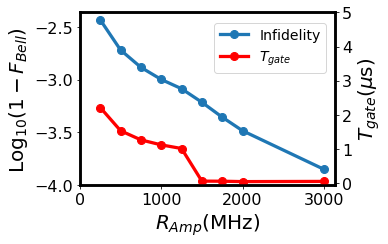

In [12]:
fig, ax1 = plt.subplots()

ax1.plot(amprange, np.log10(op_fidelity), '-o', markersize=8, linewidth=3.25, label="Infidelity")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax2 = ax1.twinx()
ax2.plot(amprange, op_tgate, '-o', markersize=8, linewidth=3.25, label=r"$T_{gate}$", color='r')

ax1.set_xlabel(r'$R_{Amp}$' '(MHz)', fontsize=20)
ax1.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=20)
ax2.set_ylabel(r'$T_{gate}(\mu$s)', fontsize=20)

plt.yticks(fontsize=16)


xinterval = np.arange(0, 3200, 1000)
y1interval = np.arange(-4, -2, 0.5)
y2interval = np.arange(0, 6, 1)
ax1.set_xticks(xinterval)
ax1.set_yticks(y1interval)
ax2.set_yticks(y2interval)

fig.legend(bbox_to_anchor=(.85, .92), fontsize=14)
plt.savefig('fig2.png', dpi=1200)